In [35]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from rate_model import RateModelWC
from rate_controller import RateControllerLin

In [36]:
def sample_disk_points_conjugate_symmetric(N: int, R: float):
    vals = []
    k = 0
    while k < N:
        if k == N - 1:
            x = np.random.uniform(-R, R)
            vals.append(complex(x, 0.0))
            k += 1
        else:
            u = np.random.rand()
            theta = 2 * np.pi * np.random.rand()
            lam = R * np.sqrt(u) * np.exp(1j * theta)

            if abs(lam.imag) < 1e-12 or np.random.rand() < 0.3:
                vals.append(complex(lam.real, 0.0))
                k += 1
            else:
                vals.append(lam)
                vals.append(np.conj(lam))
                k += 2
    return vals[:N]


def block_diag(blocks):
    n = sum(b.shape[0] for b in blocks)
    out = np.zeros((n, n), dtype=float)
    i = 0
    for b in blocks:
        m = b.shape[0]
        out[i:i+m, i:i+m] = b
        i += m
    return out


def random_W_real(N: int, R: float) -> np.ndarray:
    eigvals = sample_disk_points_conjugate_symmetric(N, R)

    blocks = []
    i = 0
    while i < N:
        lam = eigvals[i]
        if abs(lam.imag) < 1e-12:
            blocks.append(np.array([[lam.real]]))
            i += 1
        else:
            a, b = lam.real, lam.imag
            blocks.append(np.array([[a, -b],
                                    [b,  a]]))
            i += 2

    J = block_diag(blocks)

    Q = np.random.randn(N, N)
    while np.linalg.matrix_rank(Q) < N:
        Q = np.random.randn(N, N)

    W = Q @ J @ np.linalg.inv(Q)
    return W

In [37]:
def make_W_h0(model, r0, tau, R, J0=-1.0):
    r0 = np.asarray(r0).reshape(-1, 1)
    N = len(r0)

    # Gain slope at the fixed point
    gp = (model.gain_slope.reshape(-1, 1)
          * r0
          * (1 - r0 / model.rmax.reshape(-1, 1)))
    Ginv = np.diag(1 / gp.ravel())

    # Random Jacobian with spectral radius R
    J = random_W_real(N, R=R) + J0 * np.eye(N)

    # Solve for W from J = (G W - I)/tau
    W = Ginv @ (np.eye(N) + tau * J)

    # Constant input making r0 a fixed point
    h0 = model.gain_inv(r0) - W @ r0
    return W, h0, J

In [47]:
#np.random.seed(114)

# Num. populations
N = 5

tau = 1   # time constant
rho = 0.95   # spectral radius   

# Baseline rate vector
r0 = np.linspace(2, 8, N).reshape(-1, 1)

# Model
dummy_W = np.zeros((N, N))
model = RateModelWC(
    dummy_W, tau=tau, rmax=10, gain_slope=0.5, gain_center=0)
W, h0, J = make_W_h0(model, r0, tau, rho)
model.W = W

# Simulation params
T = 100
dt = 0.05
nsteps = int(T / dt)

# Add zero-mean noise around that operating point
sigma_h = 0.2
H = h0 + sigma_h * np.random.randn(N, nsteps) / np.sqrt(dt)

# Initial state
r_start = r0.copy()

Text(0.5, 0, 'Time')

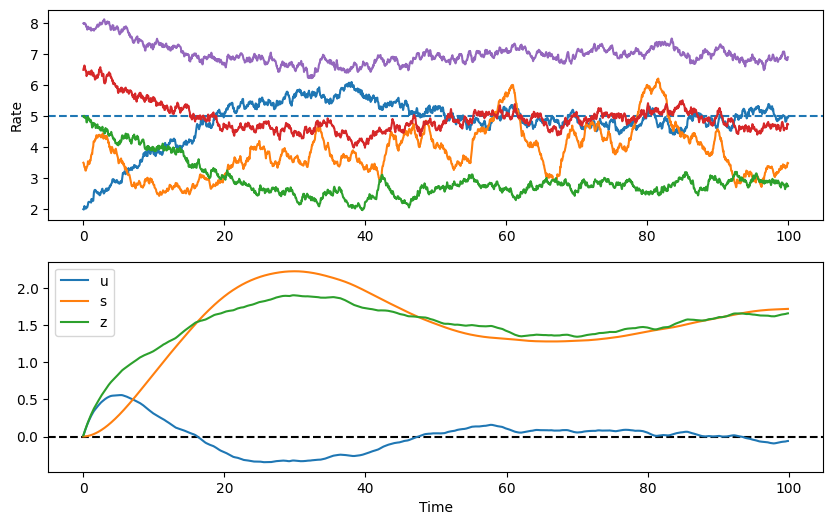

In [49]:
# Target rate
r0_target = 5
pop_ctrl = 0

# Rate controller
ctrl_par = {
    'taum': 10,
    'ks': 0.1,
    'tauu': 5,
    'ku': 0.5
}
ctrl = RateControllerLin(r0_target, **ctrl_par)
ctrl.begin(dt, nsteps, sim_res_type='full')

def rate_fb(r):
    r_ = np.asarray(r[[pop_ctrl]])
    z_ = ctrl.step(r_)['z'].item()
    z = np.zeros_like(r)
    z[pop_ctrl] = z_
    return z

# Run simulation
R = model.run(
    H, r_start, dt, nsteps,
    fb_proc=rate_fb
)
tt = R.coords['time']

# Plot result
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
for n in range(N):
    if n == pop_ctrl:
        plt.axhline(r0_target, ls='--')
    plt.plot(tt, R.isel(pop=n))
#plt.xlabel('Time')
plt.ylabel('Rate')

plt.subplot(2, 1, 2)
plt.axhline(0, ls='--', color='k')
for k in ('u', 's', 'z'):
    vv = ctrl.state_xr[k].squeeze()
    plt.plot(tt[:-1], vv[:-1], label=k)
plt.legend()
plt.xlabel('Time')
